In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Define 2 policy tensors

NUMBER_OF_SQUARES = 4

np.set_printoptions(formatter={'float': '{: 0.2f}'.format}, linewidth=100)

pi_A = np.zeros((NUMBER_OF_SQUARES, NUMBER_OF_SQUARES, 3))

for i in range(NUMBER_OF_SQUARES):
    for j in range(NUMBER_OF_SQUARES):
        pi_A[i, j, 0] = 1/8
        pi_A[i, j, 1] = 1/2
        pi_A[i, j, 2] = 3/8

pi_B = np.zeros((NUMBER_OF_SQUARES, NUMBER_OF_SQUARES, 3))

for i in range(NUMBER_OF_SQUARES):
    for j in range(NUMBER_OF_SQUARES):
        pi_B[i, j, 0] = 1/3
        pi_B[i, j, 1] = 1/3
        pi_B[i, j, 2] = 1/3

In [ ]:
def convert_indices_to_global(i, j, i_prime, j_prime):
    '''
    This is crucial!
    (i, j) position and future position of the first walker
    (i_prime, j_prime) position and future position of the second walker
    The priming indicates the second walker!
    '''
    global_i = i * NUMBER_OF_SQUARES + i_prime
    global_j = j * NUMBER_OF_SQUARES + j_prime
    return global_i, global_j

def impose_reflective_boundary_conditions(probability_tensor):
  '''
  Transfers the probability mass from the sides to the stationary state.
  This is crucial since in the simulation the walkers are not allowed to go outside the world.
  And this limit is enforced by the environment!
  '''
  for i in range(NUMBER_OF_SQUARES):
    probability_tensor[0, i, 1] += probability_tensor[0, i, 0]
    probability_tensor[0, i, 0] = 0
    probability_tensor[NUMBER_OF_SQUARES-1, i, 1] += probability_tensor[NUMBER_OF_SQUARES-1, i, 2]
    probability_tensor[NUMBER_OF_SQUARES-1, i, 2] = 0

def build_matrix_A(walker_1_prob_tensor, walker_2_prob_tensor):

  A = np.zeros((NUMBER_OF_SQUARES**2, NUMBER_OF_SQUARES**2))

  for i in range(NUMBER_OF_SQUARES):
    for j in range(NUMBER_OF_SQUARES):
      for i_prime in range(NUMBER_OF_SQUARES):
        for j_prime in range(NUMBER_OF_SQUARES):
          
          global_i, global_j = convert_indices_to_global(i, j, i_prime, j_prime)

          if np.abs(j-i) > 1 or np.abs(j_prime-i_prime) > 1:
            A[global_i, global_j] = 0

          elif j == i + 1 and j_prime == i_prime +1:
            A[global_i, global_j] = walker_1_prob_tensor[j, j_prime, 0] * walker_2_prob_tensor[j_prime, j, 0]

          elif j == i + 1 and j_prime == i_prime:
            A[global_i, global_j] = walker_1_prob_tensor[j, j_prime, 0] * walker_2_prob_tensor[j_prime, j, 1]

          elif j == i + 1 and j_prime == i_prime - 1:
            A[global_i, global_j] = walker_1_prob_tensor[j, j_prime, 0] * walker_2_prob_tensor[j_prime, j, 2]

          elif j == i and j_prime == i_prime + 1:
            A[global_i, global_j] = walker_1_prob_tensor[j, j_prime, 1] * walker_2_prob_tensor[j_prime, j, 0]

          elif j == i and j_prime == i_prime:
            A[global_i, global_j] = walker_1_prob_tensor[j, j_prime, 1] * walker_2_prob_tensor[j_prime, j, 1]

          elif j == i and j_prime == i_prime -1:
            A[global_i, global_j] = walker_1_prob_tensor[j, j_prime, 1] * walker_2_prob_tensor[j_prime, j, 2]

          elif j == i - 1 and j_prime == i_prime + 1:
            A[global_i, global_j] = walker_1_prob_tensor[j, j_prime, 2] * walker_2_prob_tensor[j_prime, j, 0]

          elif j == i - 1 and j_prime == i_prime:
            A[global_i, global_j] = walker_1_prob_tensor[j, j_prime, 2] * walker_2_prob_tensor[j_prime, j, 1]

          elif j == i - 1 and j_prime == i_prime - 1:
            A[global_i, global_j] = walker_1_prob_tensor[j, j_prime, 2] * walker_2_prob_tensor[j_prime, j, 2]
            
          else:
            raise Exception('This should not happen')

  return A

[[ 0.42  0.21  0.00  0.00  0.25  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00]
 [ 0.00  0.21  0.21  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00]
 [ 0.00  0.21  0.21  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00]
 [ 0.00  0.00  0.21  0.42  0.00  0.00  0.12  0.25  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00]
 [ 0.00  0.00  0.00  0.00  0.33  0.17  0.00  0.00  0.25  0.12  0.00  0.00  0.00  0.00  0.00  0.00]
 [ 0.00  0.00  0.00  0.00  0.00  0.17  0.17  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00  0.00]
 [ 0.00  0.00  0.00  0.00  0.00  0.17  0.17  0.00  0.00  0.12  0.12  0.00  0.00  0.00  0.00  0.00]
 [ 0.00  0.00  0.00  0.00  0.00  0.00  0.17  0.33  0.00  0.00  0.12  0.25  0.00  0.00  0.00  0.00]
 [ 0.00  0.00  0.00  0.00  0.08  0.04  0.00  0.00  0.33  0.17  0.00  0.00  0.00  0.00  0.00  0.00]
 [ 0.00  0.00  0.00  0.00  0.00  0.04  0.04  0.00  0.00  0.17  0.17  0.00  0.00  0.00  0.00  0.00]
 [ 0.00  0

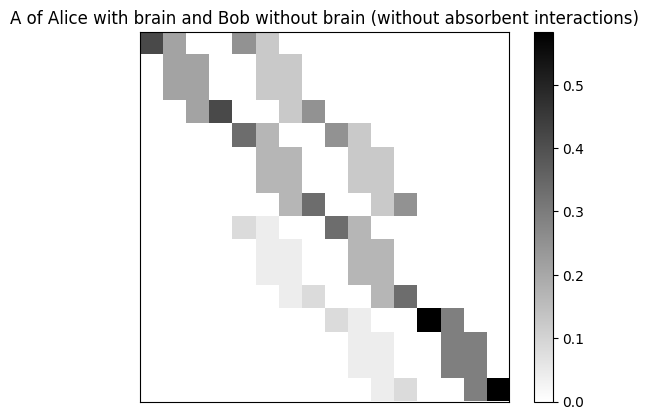

In [29]:
impose_reflective_boundary_conditions(pi_A)
impose_reflective_boundary_conditions(pi_B)

A = build_matrix_A(pi_A, pi_B)

print(A)

# Make plot
plt.imshow(A, interpolation='nearest', cmap='binary')
plt.colorbar()
plt.title('A of Alice with brain and Bob without brain (without absorbent interactions)')
plt.xticks([])
plt.yticks([])
plt.show()

